<a href="https://colab.research.google.com/github/RitajM1/arti560-computer-vision-labs/blob/main/lab04-object-detection/lab04-object-detection-exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [ ]:
!pip install keras-cv
!pip install keras-core
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 21.9 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import keras_cv
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

In [ ]:
dataset, info = tfds.load(
    "voc/2012",
    split="validation",
    with_info=True
)

images = []
labels = []

for sample in dataset.take(5):
    images.append(sample["image"])
    labels.append(sample["objects"])

In [ ]:
inference_resizing = keras_cv.layers.Resizing(
    640,
    640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)

images_resized = []

for img in images:
    img = inference_resizing(img)
    images_resized.append(img)

images_resized = tf.stack(images_resized)

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


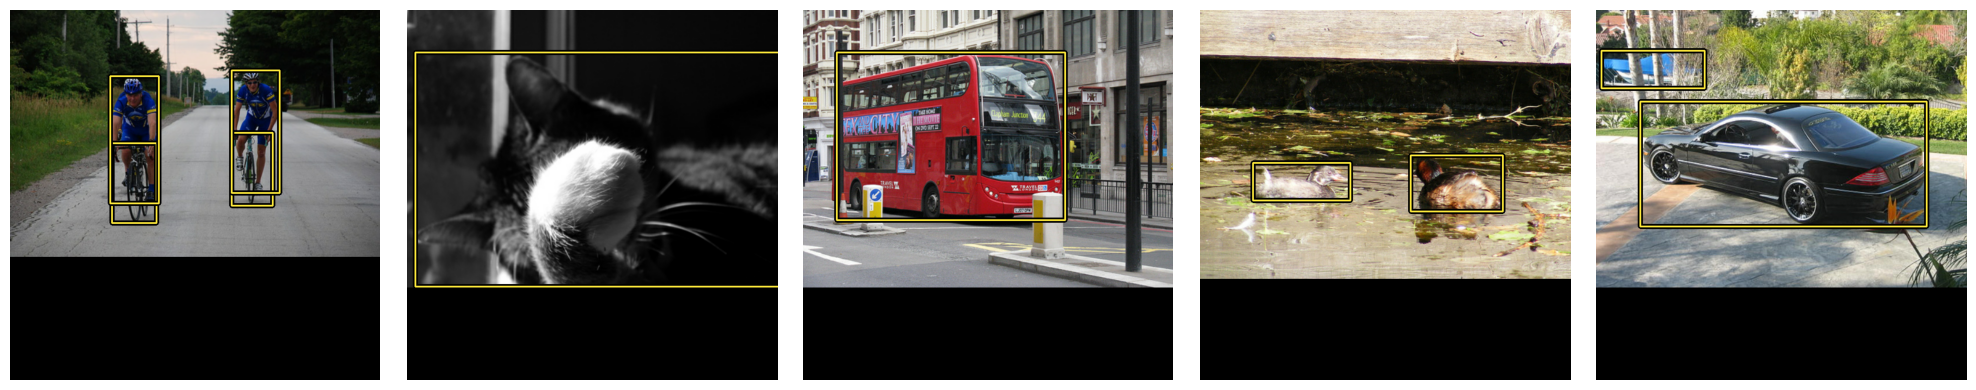


Image 1 detections:
Class: 1 | Confidence: 0.97
Class: 1 | Confidence: 0.97
Class: 14 | Confidence: 0.93
Class: 14 | Confidence: 0.93

Image 2 detections:
Class: 7 | Confidence: 0.98

Image 3 detections:
Class: 5 | Confidence: 1.00

Image 4 detections:
Class: 2 | Confidence: 0.97
Class: 11 | Confidence: 0.82

Image 5 detections:
Class: 6 | Confidence: 0.97
Class: 3 | Confidence: 0.60


In [ ]:
predictions = model.predict(images_resized)

visualization = keras_cv.visualization.plot_bounding_box_gallery(
    images_resized,
    value_range=(0,255),
    rows=1,
    cols=5,
    y_pred=predictions,
    scale=4,
    bounding_box_format="xywh",
)

plt.show()

for i, pred in enumerate(predictions["classes"]):
    print(f"\nImage {i+1} detections:")

    scores = predictions["confidence"][i]
    classes = predictions["classes"][i]

    for c, s in zip(classes, scores):
        if s > 0.4:
            print(f"Class: {int(c)} | Confidence: {float(s):.2f}")

**Image 1**

*Objects detected correctly*

Person

Bicycle

*Confidence scores*

Person: 0.97

Bicycle: 0.93

*Missed / incorrect*

No major missed objects.

Both cyclists were detected correctly.

**Image 2**

*Objects detected correctly*

Cat

*Confidence score *

Cat: 0.98

*Missed / incorrect*

No incorrect detections.

**Image 3**

*Objects detected correctly*

Bus

*Confidence score*

Bus: 1.00

*Missed / incorrect*

No incorrect detections.

**Image 4**

*Objects detected correctly*

Bird

*Confidence scores*

Bird: 0.97

Animal: 0.82

*Missed / incorrect*

One prediction labeled as Animal instead of a more specific class.

Slight label ambiguity.

**Image 5**

*Objects detected correctly*

Car

*Confidence scores*

Car: 0.97

Person: 0.60

*Missed / incorrect*

The person detection has lower confidence.

Some background regions may slightly confuse the model.